# Topic analysis Abstracts v2 — Final

**2,056 approved broad Scopus abstracts** with their exact original vectors.
Run **Clustering Abstracts Final.ipynb** first. This notebook requires its
saved Final catalog and never falls back to the original corpus.

The current selection is saved **K-means with k=6** (clusters **0–5**).
Section 5 adds two content-reviewed PE examples per cluster, using these exact
memberships and the included abstracts. Other partitions require a separate review.
Exports go to `outputs/topic_analysis_abstracts_final/`.

## 1 Load Final inputs and list saved partitions

The pinned CSV, vector rows and saved clustering catalog are validated. If the catalog is missing, run Clustering Abstracts Final.ipynb first; this topic notebook does not silently fit replacements.

In [1]:
from pathlib import Path
from html import escape
import json
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown, HTML

candidates = [Path.cwd(), Path.cwd() / 'batill', *Path.cwd().parents]
ROOT = next((p for p in candidates if (p / 'src/batill').is_dir()), None)
if ROOT is None:
    raise FileNotFoundError('Open this notebook from the batill project.')
if str(ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(ROOT / 'src'))
# Refresh helpers when rerunning in an existing notebook kernel.
# A normal import alone keeps the old functions cached in memory.
from importlib import reload
import batill.topic_analysis as topic_analysis
import batill.topic_explorer as shared_topic_explorer
import batill.abstract_topic_explorer as abstract_topic_explorer
reload(topic_analysis)
reload(shared_topic_explorer)
reload(abstract_topic_explorer)
from batill.abstract_topic_explorer import (
    load_context, partition_catalog, choose_partition, analyse_partition,
    ranked_terms, evidence_table, supporting_papers, export_analysis,
)

from batill.abstract_final import load_final_context

context = load_final_context(ROOT, build_missing=False)
print(f"Loaded {len(context['papers'])} abstract records and their existing vectors.")
print(f"Available partitions: {len(context['solutions'])}")
display(partition_catalog(context).style.hide(axis='index').format(precision=3, na_rep='—'))

Loaded 2056 abstract records and their existing vectors.
Available partitions: 32


solution,method,clusters,assigned,unassigned,cosine_silhouette,seed_ARI,resolution,seed
kmeans_k2,K-means,2,2056,0,0.056,0.711,—,11
kmeans_k3,K-means,3,2056,0,0.052,0.945,—,11
kmeans_k4,K-means,4,2056,0,0.054,0.903,—,11
kmeans_k5,K-means,5,2056,0,0.051,0.878,—,22
kmeans_k6,K-means,6,2056,0,0.056,0.849,—,33
kmeans_k7,K-means,7,2056,0,0.050,0.761,—,33
kmeans_k8,K-means,8,2056,0,0.047,0.606,—,55
kmeans_k9,K-means,9,2056,0,0.050,0.636,—,33
kmeans_k10,K-means,10,2056,0,0.049,0.628,—,55
kmeans_k11,K-means,11,2056,0,0.040,0.571,—,55


## 2 Choose the partition

The current selection is **saved K-means with k=6**, using the 2,056-paper Final
corpus. The reviewed examples in section 5 are tied to this exact partition.
If you select a different partition, rerun this cell and the cells below it;
the reviewed examples will be skipped until that partition receives its own review.

| Source | Settings used | Behaviour |
|---|---|---|
| `saved` | `SAVED_PARTITION` | Loads the exact cached partition from the table above; all fit settings are ignored. |
| `fit` with `kmeans` | `K`, `SEED`, `N_INIT` | Fits one K-means setting on the original full-dimensional vectors. |
| `fit` with `leiden` | `RESOLUTION`, `NEIGHBOURS`, `LEIDEN_SEEDS` | Uses the highest-objective seed at this resolution; `K` is ignored. |

Saved examples: `kmeans_k5`, `leiden_r0.45`, `kmeans_k6`, `leiden_r0.5`.
K-means IDs start at **0**; Leiden IDs start at **1**. All are included in analysis.
Leiden resolution determines the count; no communities are merged to impose a count.
The printed settings identify the actual partition, including resolution and seed.


In [2]:
SOURCE = 'saved'                 # 'saved' or 'fit'
SAVED_PARTITION = 'kmeans_k6'    # Reviewed examples use this exact saved six-cluster partition.

METHOD = 'leiden'                # Fit mode only: 'kmeans' or 'leiden'.
K = 5                           # Five clusters if METHOD is changed to kmeans.
RESOLUTION = 0.45                # The resulting count depends on the active corpus.
NEIGHBOURS = 15
LEIDEN_SEEDS = [42, 43, 44]      # Highest objective at this resolution wins.
SEED = 42                       # K-means only.
N_INIT = 10                      # K-means only.

# Also recover if this cell is rerun with the old six-cluster context in memory.
from importlib import reload
import batill.abstract_topic_explorer as abstract_topic_explorer
reload(abstract_topic_explorer)
from batill.abstract_topic_explorer import (
    load_context, partition_catalog, choose_partition, analyse_partition,
    ranked_terms, evidence_table, supporting_papers, export_analysis,
)
if 'sweeps' not in context.get('source_manifest', {}):
    context = load_final_context(ROOT, build_missing=False)
    print(f"Refreshed catalog: {len(context['solutions'])} available partitions.")
    display(partition_catalog(context).style.hide(axis='index').format(precision=3, na_rep='—'))

labels, partition_settings = choose_partition(
    context, source=SOURCE, saved=SAVED_PARTITION, method=METHOD,
    k=K, resolution=RESOLUTION, neighbours=NEIGHBOURS, seed=SEED, n_init=N_INIT,
    leiden_seeds=LEIDEN_SEEDS,
)
print(json.dumps(partition_settings, indent=2))
print(f"Assigned papers: {len(labels)} | Clusters: {len(set(labels))}")
print('Cluster IDs:', sorted(set(map(int, labels))))


{
  "method": "K-means",
  "clusters": 6,
  "seed": 33,
  "seeds": [
    11,
    22,
    33,
    44,
    55
  ],
  "n_init": 10,
  "inertia": 884.809814453125,
  "selection": "minimum inertia across source-notebook seeds",
  "seed_ARI": 0.8489120137534816,
  "source": "saved",
  "saved": "kmeans_k6"
}
Assigned papers: 2056 | Clusters: 6
Cluster IDs: [0, 1, 2, 3, 4, 5]


## 3 Compute the expression evidence

Text is the exact embedded **title plus cleaned abstract**. Lowercasing and
stopword removal are applied; numerical tokens and formatting terms are excluded. Adjacent-word expressions
do not bridge punctuation, stopwords or title/abstract boundaries. Singular/plural forms
and synonyms remain separate.

Two rankings are computed on the same vocabulary:

- **TF-IDF contrast:** mean normalized per-paper TF-IDF inside the cluster minus the
  mean outside. A positive score indicates greater average TF-IDF weight inside.
- **Class-based TF-IDF:** relative pooled frequency within the cluster multiplied by
  `log(1 + mean cluster vocabulary length / corpus term count)`.

Vocabulary terms must occur in at least **3 papers**, and no more than **90%** of the
analysed papers. Ranked terms additionally require a **positive score** and support
in **at least 2 cluster papers**. There is no cluster-percentage cutoff by default:
short abstracts have fewer recurring phrases than full PDFs. This allows the top
16 expressions to include more specific themes. The inside/outside counts still
show how widespread each phrase is; a high rank does not mean broad coverage.

Adjust `MIN_CLUSTER_PAPERS` and `MIN_CLUSTER_FRACTION` below if needed. Setting the
fraction to `0.10` restores the PDF notebook's 10% rule. `TOP_N` remains an upper
limit: fewer rows appear only when fewer eligible terms exist. No terms are added
or removed manually to make a cluster look more coherent.

All records are included, including K-means cluster 0. The table below makes the
analysed population explicit.


In [3]:
# Refresh the ranking code when rerunning this section in an existing kernel.
from importlib import reload
import batill.topic_analysis as topic_analysis
import batill.topic_explorer as shared_topic_explorer
import batill.abstract_topic_explorer as abstract_topic_explorer
reload(topic_analysis)
reload(shared_topic_explorer)
reload(abstract_topic_explorer)
from batill.abstract_topic_explorer import (
    analyse_partition, ranked_terms, evidence_table, supporting_papers, export_analysis,
)

MIN_CLUSTER_PAPERS = 2
MIN_CLUSTER_FRACTION = 0.0  # Use 0.10 to restore the PDF notebook's stricter rule.
analysis = analyse_partition(
    context, labels, min_df=3, max_df=0.9,
    min_cluster_papers=MIN_CLUSTER_PAPERS,
    min_cluster_fraction=MIN_CLUSTER_FRACTION,
)
print(f"Analysed papers: {len(analysis['papers'])}; vocabulary: {len(analysis['vocabulary']['terms']):,} terms")
display(analysis['summary'][['cluster', 'papers', 'minimum_support']].rename(columns={
    'cluster': 'Cluster', 'papers': 'Papers', 'minimum_support': 'Minimum supporting papers',
}).style.hide(axis='index'))
if len(analysis['unassigned']):
    display(Markdown('**Unassigned papers excluded from topic contrast:**'))
    display(analysis['unassigned'][['paper_id', 'title']].style.hide(axis='index'))

Analysed papers: 2056; vocabulary: 9,437 terms


Cluster,Papers,Minimum supporting papers
0,516,2
1,359,2
2,412,2
3,442,2
4,121,2
5,206,2


### Search a word or expression across clusters

Enter a term below and rerun only this cell to compare its frequency across the
chosen partition. **Papers containing term** counts each paper once; **total
occurrences** includes every repetition. The percentage uses the size of each
cluster; occurrences per paper includes papers with zero matches.

Search is case-insensitive and matches whole words in sequence. Hyphens are treated
as spaces; singular/plural forms are separate. Phrases cannot cross sentence or
title/abstract boundaries. Unlike ranked vocabulary, manual search also accepts rare
terms, stopwords, numbers and phrases longer than two words, without support filters.
Both title and abstract are searched. Raw occurrence counts are sensitive to text
length; paper-level prevalence counts each paper only once.

In [4]:
# Reload the helper so this new cell also works in an already-running kernel.
from importlib import reload
import batill.abstract_topic_explorer as topic_explorer
reload(topic_explorer)

SEARCH_TERM = 'private equity'   # Replace with any word or contiguous expression.
search_results = topic_explorer.search_expression(analysis, SEARCH_TERM)
print('Search:', search_results.attrs['normalized_query'])
display(search_results.style.hide(axis='index').format({
    'Papers containing term (%)': '{:.1f}', 'Occurrences per paper': '{:.2f}',
}))
print(f"Across all analysed clusters: {search_results['Papers containing term'].sum()} / "
      f"{search_results['Papers in cluster'].sum()} papers; "
      f"{search_results['Total occurrences'].sum()} occurrences.")

Search: private equity


Cluster,Papers in cluster,Papers containing term,Papers containing term (%),Total occurrences,Occurrences per paper
0,516,516,100.0,1413,2.74
1,359,359,100.0,785,2.19
2,412,412,100.0,1213,2.94
3,442,442,100.0,1534,3.47
4,121,121,100.0,207,1.71
5,206,206,100.0,807,3.92


Across all analysed clusters: 2056 / 2056 papers; 5959 occurrences.


## 4 Compare the clusters without naming them

Each cluster receives its own small table. Start with two-word expressions, then
optionally switch `TERM_KIND` to `word`. Rankings are computed separately for these
display types without changing their scores. Change `RANKING` to compare methods.

| Column | Meaning |
|---|---|
| Score | Value under the selected ranking; scores from different ranking methods are not on the same scale. |
| Inside / outside papers | Number of papers containing the term at least once, divided by the corresponding population. |
| Inside / outside % | Paper-level prevalence, regardless of repetition within a paper. |
| Gap (pp) | Inside prevalence minus outside prevalence, in percentage points. |

A contrast score and a prevalence gap measure different things: TF-IDF also considers
repetition and document normalization. A positive contrast need not imply a positive
prevalence gap. These are **descriptive statistics, not significance tests**.

In [5]:
RANKING = 'tfidf_contrast'       # Or 'c_tf_idf'.
TERM_KIND = 'expression'        # Or 'word'.
TOP_N = 16                     # Up to 16 eligible terms per cluster.

def show_terms(rows):
    if rows.empty:
        print('No terms meet the support and positive-score thresholds.')
        return
    display(evidence_table(rows).style.hide(axis='index').format({
        'Score': '{:.5f}', 'Inside %': '{:.1f}', 'Outside %': '{:.1f}', 'Gap (pp)': '{:+.1f}',
    }))

for row in analysis['summary'].itertuples():
    display(Markdown(f'### Cluster {row.cluster} — {row.papers} papers'))
    show_terms(ranked_terms(analysis, row.cluster, RANKING, TERM_KIND, TOP_N))

### Cluster 0 — 516 papers

Term,Score,Inside papers,Inside total,Outside papers,Outside total,Inside %,Outside %,Gap (pp)
leveraged buyouts,0.01220,60,516,23,1540,11.6,1.5,+10.1
pe backed,0.01126,50,516,23,1540,9.7,1.5,+8.2
equity backed,0.00950,47,516,19,1540,9.1,1.2,+7.9
equity firms,0.00708,96,516,162,1540,18.6,10.5,+8.1
pe firms,0.00696,60,516,86,1540,11.6,5.6,+6.0
target firms,0.00650,28,516,7,1540,5.4,0.5,+5.0
family firms,0.00632,20,516,8,1540,3.9,0.5,+3.4
value creation,0.00619,46,516,43,1540,8.9,2.8,+6.1
buy outs,0.00554,13,516,4,1540,2.5,0.3,+2.3
operating performance,0.00546,24,516,7,1540,4.7,0.5,+4.2


### Cluster 1 — 359 papers

Term,Score,Inside papers,Inside total,Outside papers,Outside total,Inside %,Outside %,Gap (pp)
venture capital,0.04416,199,359,133,1697,55.4,7.8,+47.6
venture capitalists,0.01191,32,359,9,1697,8.9,0.5,+8.4
vc pe,0.00998,18,359,0,1697,5.0,0.0,+5.0
pe vc,0.00899,15,359,4,1697,4.2,0.2,+3.9
early stage,0.00704,23,359,13,1697,6.4,0.8,+5.6
capital funds,0.00631,26,359,27,1697,7.2,1.6,+5.7
start ups,0.00524,14,359,5,1697,3.9,0.3,+3.6
value creation,0.00518,29,359,60,1697,8.1,3.5,+4.5
methodology approach,0.00447,36,359,49,1697,10.0,2.9,+7.1
originality value,0.00447,36,359,49,1697,10.0,2.9,+7.1


### Cluster 2 — 412 papers

...

Term,Score,Inside papers,Inside total,Outside papers,Outside total,Inside %,Outside %,Gap (pp)
equity industry,0.01198,59,442,39,1614,13.3,2.4,+10.9
emerging markets,0.00890,29,442,29,1614,6.6,1.8,+4.8
capital markets,0.00618,23,442,24,1614,5.2,1.5,+3.7
equity funds,0.00607,68,442,172,1614,15.4,10.7,+4.7
hedge funds,0.00576,29,442,29,1614,6.6,1.8,+4.8
equity market,0.00563,28,442,38,1614,6.3,2.4,+4.0
sovereign wealth,0.00434,12,442,3,1614,2.7,0.2,+2.5
financial crisis,0.00421,27,442,43,1614,6.1,2.7,+3.4
financial markets,0.00405,19,442,19,1614,4.3,1.2,+3.1
wealth funds,0.00394,12,442,4,1614,2.7,0.2,+2.5


### Cluster 4 — 121 papers

Term,Score,Inside papers,Inside total,Outside papers,Outside total,Inside %,Outside %,Gap (pp)
equity firm,0.02643,26,121,45,1935,21.5,2.3,+19.2
capital partners,0.01155,11,121,3,1935,9.1,0.2,+8.9
chemical industry,0.01142,6,121,1,1935,5.0,0.1,+4.9
smurfit group,0.01019,7,121,0,1935,5.8,0.0,+5.8
jefferson smurfit,0.01014,7,121,0,1935,5.8,0.0,+5.8
madison dearborn,0.00977,7,121,0,1935,5.8,0.0,+5.8
blackstone group,0.00934,6,121,1,1935,5.0,0.1,+4.9
new york,0.00831,8,121,4,1935,6.6,0.2,+6.4
specialty chemicals,0.00820,4,121,0,1935,3.3,0.0,+3.3
equity firms,0.00810,21,121,237,1935,17.4,12.2,+5.1


### Cluster 5 — 206 papers

Term,Score,Inside papers,Inside total,Outside papers,Outside total,Inside %,Outside %,Gap (pp)
health care,0.03892,66,206,6,1850,32.0,0.3,+31.7
equity acquisition,0.02154,46,206,8,1850,22.3,0.4,+21.9
pe ownership,0.01583,32,206,14,1850,15.5,0.8,+14.8
physician practices,0.01480,25,206,0,1850,12.1,0.0,+12.1
pe acquisitions,0.01433,27,206,1,1850,13.1,0.1,+13.1
nursing homes,0.01365,21,206,0,1850,10.2,0.0,+10.2
pe acquired,0.01364,23,206,1,1850,11.2,0.1,+11.1
equity acquisitions,0.01360,29,206,11,1850,14.1,0.6,+13.5
patient care,0.01301,26,206,0,1850,12.6,0.0,+12.6
pe acquisition,0.01218,23,206,4,1850,11.2,0.2,+10.9


## 5 Validate the cluster content with two representative papers

The supervisor's request — *“Die Cluster sollten zusätzlich anhand repräsentativer
Arbeiten inhaltlich validiert werden”* — is addressed for the saved **K-means k=6**
partition of the **2,056 Final broad Scopus abstracts**. Each pair contains two
actual members of its cluster. Cluster numbers are retained; the requested focus
phrases guide the review and do not rename the clusters.

| Cluster | Requested review focus | Papers |
|---|---|---:|
| 0 | Leveraged-buyout process and value creation | 516 |
| 1 | Venture capital with substantive PE relevance | 359 |
| 2 | Fund performance: types, risk, fees and benchmarks | 412 |
| 3 | PE industry and capital markets | 442 |
| 4 | Capital partners: coordination and partnership risk | 121 |
| 5 | Health care and nursing homes | 206 |

**Selection:** the included titles and abstracts were read for substantive PE
content and their fit to the requested focus. The two papers provide complementary
examples of each focus; they are not selected by a keyword count alone. Choices,
rationales and exact excerpts are recorded in `configs/abstract_final_cluster_examples.json`
and validated against the source CSV, embeddings and saved memberships.

**Evidence:** each example has a citation/link, an explanation, a PE-relevance
statement, two exact abstract passages and an expandable full abstract. This is
content validation from the included cleaned Scopus abstracts, not a new full-text
review. Offsets refer to characters in the cleaned abstract; no PDF page numbers
are assigned. Source metadata and Scopus IDs make every selection traceable.

**Diagnostics:** centrality rank orders papers by mean cosine similarity to the
other title-and-abstract vectors in their cluster (rank 1 is most central). Cosine
silhouette measures separation from other clusters. These describe the selected
papers, rather than acting as automatic inclusion thresholds. A negative silhouette
marks a boundary case and does not itself justify removing a paper.

**Cluster 4 has limited support for the requested interpretation.** Many central
records describe acquisitions, including chemical-industry transactions, and
“Capital Partners” can be an investor name. The HCA and Heinz case studies provide
substantive PE examples of contracting and partnership risk, but neither establishes
how to find a capital partner. Both are thematic boundary examples with negative
silhouettes. This limitation is part of the validation result; the pair does not
establish a coherent partner-selection theme for the whole cluster.

The examples support particular strands rather than proving whole-cluster uniformity.
Cluster 1 deliberately retains joint VC/PE research; its combined VC/PE findings
are not presented as PE-only effects. Scope notes distinguish frameworks, reviews,
case studies and observational evidence. The boundary and random examples in the
next section remain useful for challenging an interpretation.

The **12 examples**, **24 passages** and diagnostics for **all 2,056 papers** are
saved automatically under `reports/abstract_final_cluster_examples/<review-checksum>/`.


In [6]:
from importlib import reload
from urllib.parse import quote
import batill.abstract_final_cluster_examples as abstract_examples
reload(abstract_examples)
from batill.storage import read_json

REVIEW_CONFIG = ROOT / 'configs/abstract_final_cluster_examples.json'
representative_review = read_json(REVIEW_CONFIG)
if (partition_settings.get('source') != 'saved'
        or partition_settings.get('saved') != representative_review['solution']):
    display(Markdown('These reviewed examples belong to **saved `kmeans_k6`** on the '
                     '**2,056-paper Final corpus**. Select that partition in section 2 '
                     'and rerun to display them; other partitions need a separate content review.'))
else:
    representatives, representative_passages, representative_diagnostics = abstract_examples.representative_papers(
        context, analysis, partition_settings, representative_review,
    )
    source_url = quote(representative_review['source_csv'], safe='/')
    for cluster in sorted(representatives.cluster.unique()):
        focus = representative_review['focus'][str(cluster)]
        display(Markdown(f'### Cluster {cluster}\n\n**Requested focus:** {focus}'))
        cluster_note = representative_review.get('cluster_review_notes', {}).get(str(cluster))
        if cluster_note:
            display(Markdown(f'**Interpretation:** {cluster_note}'))
        for paper in representatives.loc[representatives.cluster.eq(cluster)].itertuples():
            paper_url = 'https://doi.org/' + quote(paper.doi, safe='/') if paper.doi else paper.url
            diagnostics = (f'Abstract-vector centrality rank {paper.centrality_rank}/{paper.cluster_papers}; '
                           f'mean within-cluster cosine {paper.mean_within_cluster_cosine:.3f}; '
                           f'cosine silhouette {paper.cosine_silhouette:+.3f}')
            if paper.cosine_silhouette < 0:
                diagnostics += ' — thematic boundary example'
            passages_html = []
            for passage in representative_passages.loc[representative_passages.paper_id.eq(paper.paper_id)].itertuples():
                passages_html.append(
                    f'<p><strong>Included cleaned abstract</strong> — characters '
                    f'{passage.excerpt_start}–{passage.excerpt_end} (zero-based, end exclusive)</p>'
                    f'<blockquote style="white-space:pre-wrap">{escape(passage.excerpt)}</blockquote>')
            display(HTML(
                '<div class="reviewed-abstract-example" style="border-left:3px solid #46758c;padding:0 1em;margin:1em 0 1.6em">'
                f'<h4>{escape(paper.citation)}<br>'
                f'<a href="{escape(paper_url, quote=True)}" target="_blank">{escape(paper.title)}</a></h4>'
                f'<p>{escape(paper.authors)} · {escape(paper.journal)} · {escape(paper.year)} '
                f'· {escape(paper.document_type)}<br>Scopus ID: {escape(paper.paper_id)}</p>'
                f'<p><strong>Role in this pair:</strong> {escape(paper.role)}</p>'
                f'<p><strong>Why selected:</strong> {escape(paper.why_representative)}</p>'
                f'<p><strong>Private-equity relevance:</strong> {escape(paper.private_equity_focus)}</p>'
                f'<p><strong>Diagnostic context:</strong> {escape(diagnostics)}</p>'
                f'<p><strong>Scope and interpretation:</strong> {escape(paper.scope_note)}</p>'
                '<details><summary>Read the two supporting passages</summary>'
                + ''.join(passages_html) + '</details>'
                '<details><summary>Full included abstract and source</summary>'
                f'<p><a href="{source_url}" target="_blank">Included source CSV</a> · '
                f'<a href="{escape(paper.url, quote=True)}" target="_blank">Scopus source record</a> '
                f'· source record {escape(paper.source_record)}</p>'
                f'<p style="white-space:pre-wrap">{escape(paper.abstract)}</p>'
                '</details></div>'
            ))
    representative_export = abstract_examples.export_representative_papers(
        context, REVIEW_CONFIG, representative_review, representatives,
        representative_passages, representative_diagnostics, partition_settings,
    )
    print(f'Saved {len(representatives)} examples and {len(representative_passages)} passages:')
    print(representative_export)


### Cluster 0

**Requested focus:** leveraged-buyout process and value creation

### Cluster 1

**Requested focus:** venture capital with substantive private-equity relevance

### Cluster 2

**Requested focus:** fund performance across fund types, risk, fees and benchmarks

### Cluster 3

**Requested focus:** private-equity industry and capital markets

### Cluster 4

**Requested focus:** capital partners: deal coordination and partnership risk

**Interpretation:** Limited validation of the requested focus. Many central records report PE acquisitions, including chemical-industry transactions; “Capital Partners” also occurs in investor names. The two selected academic cases concern deal partners and contractual risk, but neither demonstrates how to find partners. Both have negative cosine silhouettes and are thematic boundary examples. Do not infer a coherent partner-selection cluster from these two cases.

### Cluster 5

**Requested focus:** health care and nursing homes

Saved 12 examples and 24 passages:
/Users/tilldedek/Documents/Semester 6/Bachelorarbeit/Python/batill/reports/abstract_final_cluster_examples/0b52c01aec329361


## 6 Inspect one cluster more closely

Choose a numeric cluster ID. Both rankings appear below, followed by a coverage plot
for the ranking selected above. Agreement between rankings is useful context, but both
use the same underlying text and are not independent validation.

In [7]:
CLUSTER = int(min(analysis['labels']))  # Replace with a cluster ID from the table.
DETAIL_TOP_N = 12
if CLUSTER not in set(analysis['labels']):
    raise ValueError(f"Choose one of {sorted(set(analysis['labels']))}")
for method, title in [('tfidf_contrast', 'TF-IDF contrast'), ('c_tf_idf', 'Class-based TF-IDF')]:
    display(Markdown(f'### Cluster {CLUSTER}: {title}'))
    show_terms(ranked_terms(analysis, CLUSTER, method, TERM_KIND, DETAIL_TOP_N))

### Cluster 0: TF-IDF contrast

Term,Score,Inside papers,Inside total,Outside papers,Outside total,Inside %,Outside %,Gap (pp)
leveraged buyouts,0.01220,60,516,23,1540,11.6,1.5,+10.1
pe backed,0.01126,50,516,23,1540,9.7,1.5,+8.2
equity backed,0.00950,47,516,19,1540,9.1,1.2,+7.9
equity firms,0.00708,96,516,162,1540,18.6,10.5,+8.1
pe firms,0.00696,60,516,86,1540,11.6,5.6,+6.0
target firms,0.00650,28,516,7,1540,5.4,0.5,+5.0
family firms,0.00632,20,516,8,1540,3.9,0.5,+3.4
value creation,0.00619,46,516,43,1540,8.9,2.8,+6.1
buy outs,0.00554,13,516,4,1540,2.5,0.3,+2.3
operating performance,0.00546,24,516,7,1540,4.7,0.5,+4.2


### Cluster 0: Class-based TF-IDF

Term,Score,Inside papers,Inside total,Outside papers,Outside total,Inside %,Outside %,Gap (pp)
equity firms,0.01442,96,516,162,1540,18.6,10.5,+8.1
pe backed,0.01144,50,516,23,1540,9.7,1.5,+8.2
pe firms,0.00963,60,516,86,1540,11.6,5.6,+6.0
leveraged buyouts,0.00963,60,516,23,1540,11.6,1.5,+10.1
equity backed,0.00798,47,516,19,1540,9.1,1.2,+7.9
value creation,0.00764,46,516,43,1540,8.9,2.8,+6.1
equity investors,0.00705,43,516,89,1540,8.3,5.8,+2.6
buy outs,0.00685,13,516,4,1540,2.5,0.3,+2.3
corporate governance,0.00671,41,516,48,1540,7.9,3.1,+4.8
family firms,0.00575,20,516,8,1540,3.9,0.5,+3.4


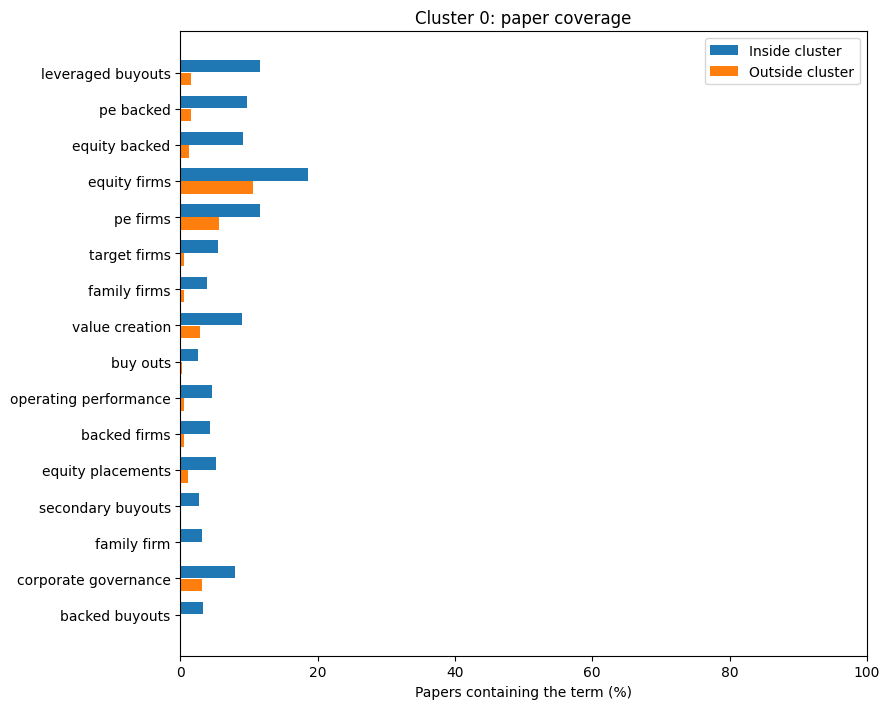

In [8]:
selected_terms = ranked_terms(analysis, CLUSTER, RANKING, TERM_KIND, TOP_N)
if not selected_terms.empty:
    plot_rows = selected_terms.iloc[::-1]
    y = np.arange(len(plot_rows))
    fig, ax = plt.subplots(figsize=(9, max(3, 0.45 * len(plot_rows))))
    ax.barh(y + 0.18, 100 * plot_rows.inside_prevalence, height=0.35, label='Inside cluster')
    ax.barh(y - 0.18, 100 * plot_rows.outside_prevalence, height=0.35, label='Outside cluster')
    ax.set(yticks=y, yticklabels=plot_rows.term, xlim=(0, 100),
           xlabel='Papers containing the term (%)', title=f'Cluster {CLUSTER}: paper coverage')
    ax.legend()
    fig.tight_layout()
    plt.show()

### Paper examples and possible counterexamples

Three representatives have the highest average cosine similarity to their cluster's
other papers. Two boundary examples have the lowest cosine silhouette. Up to two
further papers are sampled with a fixed seed. A paper may have more than one role.

Expand a paper to inspect its saved abstract excerpt and full cleaned abstract.
Excerpt offsets refer to characters in that abstract. Excerpts are usually selected
around highly ranked terms. A low silhouette is not evidence that a paper should
be excluded.


In [9]:
review = analysis['examples'].loc[analysis['examples'].cluster == CLUSTER]
display(review[['paper_id', 'title', 'selection', 'cosine_silhouette']].style.hide(axis='index')
        .format({'cosine_silhouette': '{:.3f}'}).set_properties(**{'white-space': 'normal'}))
for paper in review.itertuples():
    heading = escape(f'{paper.paper_id} — {paper.title} ({paper.selection})')
    location = escape(f'Abstract characters {paper.excerpt_start}–{paper.excerpt_end}; '
                      f'selected term: {paper.term or "none"}')
    display(HTML(f'<details><summary>{heading}</summary><p>{location}</p>'
                 f'<p style="white-space:pre-wrap">{escape(paper.excerpt)}</p>'
                 f'<details><summary>Full cleaned abstract</summary>'
                 f'<p style="white-space:pre-wrap">{escape(paper.abstract)}</p>'
                 f'</details></details>'))


paper_id,title,selection,cosine_silhouette
2-s2.0-67049110349,Private equity and corporate governance: Retrospect and prospect,representative,0.096
2-s2.0-105011353220,"Impact of Private Equity Ownership on Firm Performance: An Operational, Financial, and Strategic Analysis",representative,0.080
2-s2.0-84957433962,Does ownership matter in private equity? the sources of variance in buyouts' performance,representative,0.121
2-s2.0-85144492989,Effects of chain ownership and private equity financing on quality in the English care home sector: retrospective observational study,boundary,-0.049
2-s2.0-85130529498,Private equity and Covid-19,boundary,-0.032
2-s2.0-105029733514,Environmental and social incidents and misvaluation-driven leveraged buyouts,random,0.098
2-s2.0-77956880587,Private Equity and the Public Good,random,0.064


## 7 Trace a specific expression to its papers

Copy an exact term from a table into `EXPRESSION`, or leave it as `None` to use the
first term in the selected cluster/ranking. Support uses the whole-word search from section 3, including hyphen normalization;
ranked expressions use the same contiguous wording. Each paper counts once for coverage;
the occurrence count is provided separately. Supporting papers outside the cluster
help distinguish a specific theme from vocabulary shared across the literature.

In [10]:
EXPRESSION = None               # For example, copy an expression from your table.
SUPPORT_ROWS = 20              # Display limit only; export includes every supporting paper.
selected_terms = ranked_terms(analysis, CLUSTER, RANKING, TERM_KIND, TOP_N)
selected_expression = EXPRESSION or (selected_terms.iloc[0].term if len(selected_terms) else None)
support = None
if selected_expression is None:
    print('No eligible term in this view. Choose another cluster or term kind.')
else:
    support = supporting_papers(analysis, selected_expression, CLUSTER)
    n_inside = int((analysis['labels'] == CLUSTER).sum())
    print(f'Expression: {selected_expression}')
    print(f'Inside: {support.inside.sum()}/{n_inside}; outside: {(~support.inside).sum()}/{len(analysis["papers"]) - n_inside}')
    for inside, title in [(True, 'Inside cluster'), (False, 'Outside cluster')]:
        group = support.loc[support.inside == inside]
        display(Markdown(f'### {title}: showing {min(SUPPORT_ROWS, len(group))} of {len(group)} supporting papers'))
        display(group[['paper_id', 'title', 'cluster', 'occurrences', 'source_field']].head(SUPPORT_ROWS)
                .style.hide(axis='index').set_properties(**{'white-space': 'normal'}))

Expression: leveraged buyouts
Inside: 60/516; outside: 23/1540


### Inside cluster: showing 20 of 60 supporting papers

paper_id,title,cluster,occurrences,source_field
2-s2.0-105004916676,Leveraged buyouts in Spain: Organic growth or industry consolidation?,0,4,title
2-s2.0-105004721536,Do Employees Cheer for Private Equity? The Heterogeneous Effects of Buyouts on Job Quality,0,1,abstract
2-s2.0-105029733514,Environmental and social incidents and misvaluation-driven leveraged buyouts,0,2,title
2-s2.0-105017966215,Private equity acquisitions and product market decisions: Evidence from trademarks,0,1,abstract
2-s2.0-85193518878,"Social capital, syndication, and investment performance: Evidence from PE investing in LBOs",0,1,abstract
2-s2.0-85191330410,Spillovers of PE investments,0,1,abstract
2-s2.0-85121314985,Impact of Sarbanes Oxley Act on initial public offerings: new evidence from reverse leveraged buyouts,0,1,title
2-s2.0-105004690726,Use of proceeds in private equity-backed initial public offerings,0,1,abstract
2-s2.0-85182644900,Financial resource pooling in club deals,0,1,abstract
2-s2.0-85120973726,Global leveraged buyout deal performance: A cross-border cross-cultural perspective,0,1,abstract


### Outside cluster: showing 20 of 23 supporting papers

paper_id,title,cluster,occurrences,source_field
2-s2.0-105016811051,Performance Perspectives on Prominent Private Equity-Leveraged Buyout Fund (PE-LBO) Families,2,1,abstract
2-s2.0-105029523612,Private equity investment in orthopedic practices: Part of the changing landscape of health care,5,1,abstract
2-s2.0-105028951691,Private Equity in US Healthcare: Issues and Developments,5,1,abstract
2-s2.0-85167685567,Private Equity and the Corporatization of Health Care,5,1,abstract
2-s2.0-85168564264,Private Equity Looting of U.S. Health Care: An Under-Recognized and Uncontrolled Scourge,5,1,abstract
2-s2.0-85152173391,A Systematic Review: Landscape of Private Equity in Dermatology From Past to Present,5,1,abstract
2-s2.0-85120075784,Hospital ownership and financial stability: A matched case comparison of a nonprofit health system and a private equity–owned health system,5,1,abstract
2-s2.0-85105278779,"Private equity investments in health care: An overview of hospital and health system leveraged buyouts, 2003–17",5,1,title
2-s2.0-85136724693,"Defense Contractors, Private Equity Firms, and US National Security",3,1,abstract
2-s2.0-85143423714,WHY ARE PRIVATE EQUITY TRANSACTIONS INSURED? A NEO-INSTITUTIONAL THEORY PERSPECTIVE,3,1,abstract


In [11]:
PAPER_ID = None                 # Copy a paper_id above, or inspect the first supporting paper.
if support is not None and len(support):
    inspected = support.iloc[0] if PAPER_ID is None else support.set_index('paper_id').loc[PAPER_ID]
    display(Markdown(f'**Source field: {inspected.source_field}**'))
    display(HTML(f'<p>{escape(inspected.title)}</p><pre style="white-space:pre-wrap">'
                 f'{escape(inspected.passage)}</pre>'))

**Source field: title**

## 8 Save evidence for your interpretation

Set `SAVE_RESULTS = True` when you want a permanent record. Each export creates a new
folder under `outputs/topic_analysis_abstracts_final`; previous evidence is never replaced.

It contains full eligible word/expression rankings for both methods, cluster sizes,
membership, review papers with excerpts and full abstracts, supporting papers for
the selected expression, and a manifest of parameters, input hashes and software versions.
Scores and proportions are saved at full precision. Plot display is not required for reproduction.

When you later name a cluster, record which expressions and papers support the name,
which papers challenge it, and the exported run folder. Inspect broad methodological vocabulary, synonyms and mixed subject matter before
interpreting a ranking. A descriptive label should remain open to revision.

The curated section-5 examples are exported separately and automatically to
`reports/abstract_final_cluster_examples/<review-checksum>/`.


In [12]:
SAVE_RESULTS = True
if SAVE_RESULTS:
    exported = export_analysis(analysis, context, partition_settings, support=support,
        display_settings=dict(cluster=CLUSTER, ranking=RANKING, kind=TERM_KIND,
                              top_n=TOP_N, detail_top_n=DETAIL_TOP_N, expression=selected_expression))
    print('Saved evidence:', exported)
else:
    print('Full expression-evidence export disabled. Section 5 exports its reviewed examples separately.')

Saved evidence: /Users/tilldedek/Documents/Semester 6/Bachelorarbeit/Python/batill/outputs/topic_analysis_abstracts_final/20261006T145643397721Z_9839c3ae


## Export additional saved partitions

Keep the existing companion topic tables for `kmeans_k5` and `leiden_r0.45`.
The interactive view and reviewed examples above use **kmeans_k6**. These companions
belong to this 2,056-paper corpus; the age notebook has its own corpus and selection.


In [13]:
for companion in ('kmeans_k5', 'leiden_r0.45'):
    if partition_settings.get('saved') == companion:
        continue
    companion_labels, companion_settings = choose_partition(context, source='saved', saved=companion)
    companion_analysis = analyse_partition(context, companion_labels, min_df=3, max_df=0.9,
        min_cluster_papers=MIN_CLUSTER_PAPERS, min_cluster_fraction=MIN_CLUSTER_FRACTION)
    companion_export = export_analysis(companion_analysis, context, companion_settings,
        display_settings={'ranking': RANKING, 'kind': TERM_KIND, 'top_n': TOP_N})
    print('Saved companion topic evidence:', companion, companion_export)

Saved companion topic evidence: kmeans_k5 /Users/tilldedek/Documents/Semester 6/Bachelorarbeit/Python/batill/outputs/topic_analysis_abstracts_final/20261006T145644716208Z_9360252d
Saved companion topic evidence: leiden_r0.45 /Users/tilldedek/Documents/Semester 6/Bachelorarbeit/Python/batill/outputs/topic_analysis_abstracts_final/20261006T145645752934Z_fc28b9a9
